# Explicabilidad del mejor modelo: SHAP y LIME

Este notebook interpreta el mejor modelo supervisado real: **`LightGBM_con_smote`**. En las comparativas, `LightGBM_con_smote` obtiene el mejor PR-AUC real (**0.9269**) y el ensemble ponderado acaba asignándole peso 1.0, por lo que la explicación se centra en este pipeline.

Se utilizan dos enfoques:

- **SHAP** para explicabilidad global y local basada en contribuciones de variables.
- **LIME** para explicar predicciones individuales de forma local.

La interpretación se realiza sobre las variables transformadas por el preprocesador del pipeline, incluyendo variables one-hot de categorías.

## Librerías y configuración

In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd

from IPython.display import HTML, display

from sklearn.metrics import average_precision_score, classification_report, confusion_matrix, fbeta_score, roc_auc_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
SHAP_SAMPLE_SIZE = 3000
LIME_TRAIN_SAMPLE_SIZE = 5000

/opt/miniconda3/envs/tfg_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Carga de datos y modelo

In [2]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = project_root / "data" / "clean"
models_path = project_root / "models"

X = pd.read_csv(data_path / "X_clean.csv")
y = pd.read_csv(data_path / "y.csv").squeeze("columns")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

model_path = models_path / "retrained_best_models" / "LightGBM_con_smote.joblib"
if not model_path.exists():
    model_path = models_path / "best_fraud_pipeline.joblib"

model = joblib.load(model_path)
print("Modelo cargado:", model_path)
print("Train:", X_train.shape, "Test:", X_test.shape)

Modelo cargado: /Users/aldan/Desktop/tfg_code/models/retrained_best_models/LightGBM_con_smote.joblib
Train: (475714, 10) Test: (118929, 10)


## Evaluación rápida del modelo cargado

In [3]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_proba), 4))
print("F2:", round(fbeta_score(y_test, y_pred, beta=2), 4))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["legitima", "fraude"]))

ROC-AUC: 0.9984
PR-AUC: 0.9269
F2: 0.8433
Matriz de confusión:
[[117314    175]
 [   236   1204]]

Classification report:
              precision    recall  f1-score   support

    legitima       1.00      1.00      1.00    117489
      fraude       0.87      0.84      0.85      1440

    accuracy                           1.00    118929
   macro avg       0.94      0.92      0.93    118929
weighted avg       1.00      1.00      1.00    118929



## Preparación de datos transformados

El pipeline contiene un preprocesador y un clasificador LightGBM. Para SHAP y LIME se transforma primero `X` con el preprocesador y después se explica el clasificador final.

In [4]:
# En el pipeline con SMOTENC, el primer paso es SMOTE y el segundo es el preprocesador.
if "preprocessor" in model.named_steps:
    preprocessor = model.named_steps["preprocessor"]
elif "preprocess" in model.named_steps:
    preprocessor = model.named_steps["preprocess"]
else:
    raise KeyError("No se encontró el paso de preprocesamiento en el pipeline.")

if "classifier" in model.named_steps:
    classifier = model.named_steps["classifier"]
elif "model" in model.named_steps:
    classifier = model.named_steps["model"]
else:
    raise KeyError("No se encontró el clasificador final en el pipeline.")

feature_names = preprocessor.get_feature_names_out()

shap_idx = X_test.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_test)),
    random_state=RANDOM_STATE,
).index
X_shap_raw = X_test.loc[shap_idx]
y_shap = y_test.loc[shap_idx]

X_train_lime_raw = X_train.sample(
    n=min(LIME_TRAIN_SAMPLE_SIZE, len(X_train)),
    random_state=RANDOM_STATE,
)

X_shap_transformed = preprocessor.transform(X_shap_raw)
X_train_lime_transformed = preprocessor.transform(X_train_lime_raw)

# SHAP y LIME trabajan con arrays densos en esta configuración. La muestra está limitada para controlar memoria.
X_shap_dense = X_shap_transformed.toarray() if hasattr(X_shap_transformed, "toarray") else np.asarray(X_shap_transformed)
X_train_lime_dense = X_train_lime_transformed.toarray() if hasattr(X_train_lime_transformed, "toarray") else np.asarray(X_train_lime_transformed)

print("Muestra SHAP:", X_shap_dense.shape)
print("Muestra LIME train:", X_train_lime_dense.shape)
print("Número de features transformadas:", len(feature_names))

Muestra SHAP: (3000, 4115)
Muestra LIME train: (5000, 4115)
Número de features transformadas: 4115


## SHAP global

El gráfico resume qué variables transformadas tienen mayor impacto en la probabilidad de fraude. En variables categóricas, los nombres con prefijo `cat__` representan categorías concretas generadas por one-hot encoding.

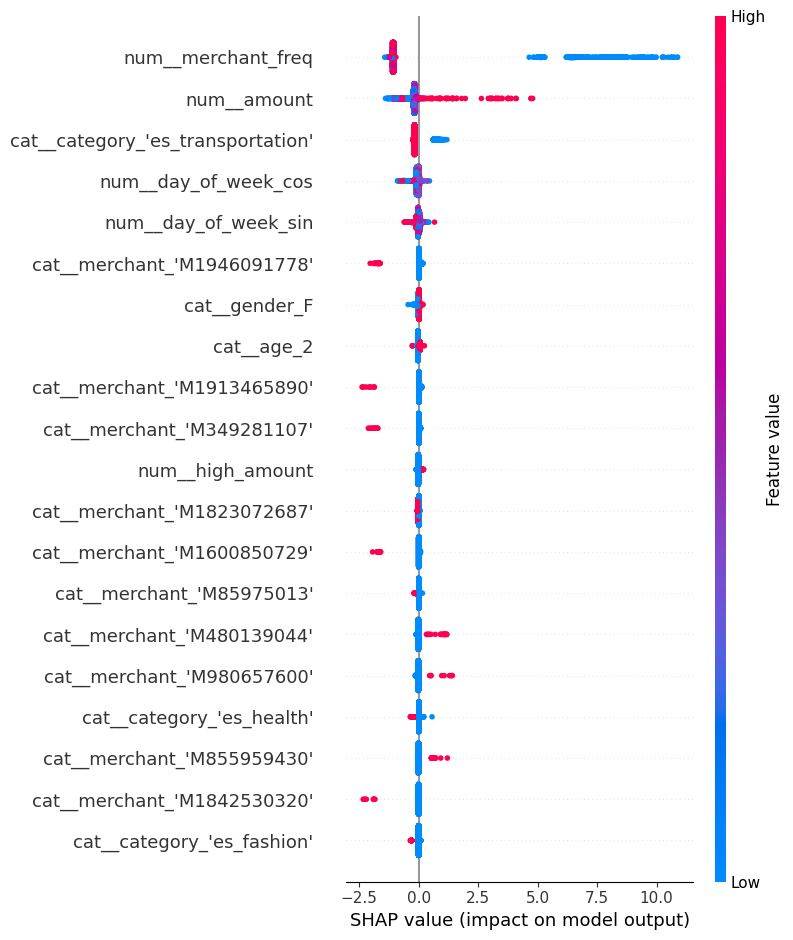

In [5]:
explainer = shap.TreeExplainer(classifier)
shap_values = explainer(X_shap_dense)

# En clasificación binaria, algunas versiones devuelven valores con dimensión final por clase.
if len(shap_values.values.shape) == 3:
    shap_values_to_plot = shap.Explanation(
        values=shap_values.values[:, :, 1],
        base_values=shap_values.base_values[:, 1],
        data=X_shap_dense,
        feature_names=feature_names,
    )
else:
    shap_values_to_plot = shap.Explanation(
        values=shap_values.values,
        base_values=shap_values.base_values,
        data=X_shap_dense,
        feature_names=feature_names,
    )

shap.summary_plot(shap_values_to_plot, features=X_shap_dense, feature_names=feature_names, max_display=20)

In [6]:
mean_abs_shap = np.abs(shap_values_to_plot.values).mean(axis=0)
shap_importance = (
    pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .head(25)
)
display(shap_importance)

,feature,mean_abs_shap
4114,num__merchant_freq,1.702770
4110,num__amount,0.290127
4107,cat__category_'es_transportation',0.262829
4113,num__day_of_week_cos,0.084553
4112,num__day_of_week_sin,0.048356
4068,cat__merchant_'M1946091778',0.042487
4043,cat__gender_F,0.038133
4036,cat__age_2,0.034738
4067,cat__merchant_'M1913465890',0.027305
4075,cat__merchant_'M349281107',0.022857


## SHAP local

Se explican dos casos concretos: una transacción fraudulenta con probabilidad alta y una transacción legítima con probabilidad baja.

In [ ]:
sample_proba = model.predict_proba(X_shap_raw)[:, 1]
local_df = pd.DataFrame({
    "shap_position": np.arange(len(X_shap_raw)),
    "original_index": X_shap_raw.index,
    "fraud_real": y_shap.values,
    "proba_fraude": sample_proba,
}).sort_values("proba_fraude", ascending=False)

display(local_df.head(10))
display(local_df.tail(10))

In [ ]:
fraud_candidates = local_df[local_df["fraud_real"] == 1]
legit_candidates = local_df[local_df["fraud_real"] == 0]

fraud_position = int(fraud_candidates.iloc[0]["shap_position"]) if len(fraud_candidates) else int(local_df.iloc[0]["shap_position"])
legit_position = int(legit_candidates.iloc[-1]["shap_position"]) if len(legit_candidates) else int(local_df.iloc[-1]["shap_position"])

print("Explicación local de caso con fraude/probabilidad alta")
print("Índice original:", X_shap_raw.index[fraud_position])
print("Probabilidad fraude:", round(sample_proba[fraud_position], 4))
print("Etiqueta real:", y_shap.iloc[fraud_position])
shap.plots.waterfall(shap_values_to_plot[fraud_position], max_display=15)

print("Explicación local de caso legítimo/probabilidad baja")
print("Índice original:", X_shap_raw.index[legit_position])
print("Probabilidad fraude:", round(sample_proba[legit_position], 4))
print("Etiqueta real:", y_shap.iloc[legit_position])
shap.plots.waterfall(shap_values_to_plot[legit_position], max_display=15)

## LIME local

LIME aproxima localmente el comportamiento del modelo alrededor de una observación. Aquí se aplica sobre las variables transformadas por el preprocesador.

In [ ]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime_dense,
    feature_names=list(feature_names),
    class_names=["legitima", "fraude"],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)


def classifier_predict_from_transformed(X_transformed_dense):
    return classifier.predict_proba(X_transformed_dense)

lime_case_position = fraud_position
lime_exp = lime_explainer.explain_instance(
    X_shap_dense[lime_case_position],
    classifier_predict_from_transformed,
    num_features=15,
)

print("Índice original:", X_shap_raw.index[lime_case_position])
print("Probabilidad predicha de fraude:", round(sample_proba[lime_case_position], 4))
print("Etiqueta real:", y_shap.iloc[lime_case_position])

# Evitamos lime_exp.show_in_notebook(), que falla en algunas versiones recientes de IPython.
display(HTML(lime_exp.as_html(show_table=True)))

In [ ]:
lime_table = pd.DataFrame(lime_exp.as_list(), columns=["feature_rule", "local_weight"])
display(lime_table)

## Conclusiones de SHAP y LIME

El modelo explicado es `LightGBM_con_smote`, que mantiene un rendimiento alto en test: **PR-AUC = 0.9269**, **ROC-AUC = 0.9984** y **F2 = 0.8433**. Detecta **1204 de 1440 fraudes**, con **236 falsos negativos** y **175 falsos positivos**.

### Conclusión SHAP

SHAP muestra que el modelo no decide principalmente por una sola variable aislada, pero sí hay una señal dominante: **`merchant_freq`** es, con mucha diferencia, la variable más influyente (`mean_abs_shap = 1.7028`). Esto indica que la frecuencia del comercio es clave para separar patrones normales de patrones sospechosos.

Después aparecen variables muy coherentes con el problema de fraude:

- **`amount`** (`mean_abs_shap = 0.2901`): el importe de la operación tiene un peso importante.
- **`category_es_transportation`** (`0.2628`): la categoría de transporte marca mucho la decisión del modelo, probablemente porque concentra gran parte del comportamiento no fraudulento o patrones muy diferenciados.
- **variables temporales** como `day_of_week_cos` y `day_of_week_sin`: el momento temporal de la transacción aporta señal.
- **merchants concretos** como `M1946091778`, `M1913465890`, `M349281107`, etc.: ciertos comercios tienen patrones asociados a mayor o menor riesgo.
- **`high_amount`**, aunque aparece por debajo de `amount`, confirma que los importes altos aportan información adicional.

La lectura global es que el modelo combina tres tipos de señal: comportamiento del comercio, importe de la operación y categoría/timing de la transacción. Esto es razonable para fraude: no solo importa cuánto se gasta, sino dónde, en qué categoría y bajo qué patrón de frecuencia.

### Conclusión LIME

LIME se aplicó a una transacción fraudulenta concreta con probabilidad predicha muy alta: **0.9990** para fraude, con etiqueta real **fraude**. La explicación local salió dominada por variables one-hot de `customer`, por ejemplo reglas del tipo `cat__customer_... > 0` o `cat__customer_... <= 0`.

Esto tiene una interpretación importante: para esa predicción concreta, el modelo está usando patrones muy específicos asociados a clientes codificados en one-hot. LIME confirma que la decisión local se apoya en señales particulares de identidad/comportamiento del cliente, pero esa explicación es menos clara a nivel de negocio porque aparecen muchos identificadores individuales.

Por tanto, **SHAP es más útil para la interpretación global del TFG**, porque permite explicar qué familias de variables gobiernan el modelo. **LIME es útil como apoyo local**, para justificar una predicción individual, pero en este dataset queda menos interpretable por la alta cardinalidad de `customer` y `merchant`.

### Conclusión final

La explicabilidad respalda el modelo supervisado: `LightGBM_con_smote` no funciona como una caja negra arbitraria, sino que basa sus decisiones en variables coherentes con fraude: frecuencia del comercio, importe, categoría, momento temporal y entidades concretas con patrones de riesgo. Para presentar el resultado, usaría SHAP como explicación principal y LIME como ejemplo local complementario.